# Notebook 5 — Análisis estadístico de la calidad del aire (CDMX)

Fuente de datos: https://aire.cdmx.gob.mx (Datos → Contaminante), agencia SIMAT.

Formato real de los CSV: traen ~9 líneas de metadata (ciudad, agencia, rango de fechas, versión)
antes de la tabla. La tabla tiene columnas: `date`, `id_station`, `id_parameter`, `valor`, `unit`.

Flujo de trabajo:
1. Proceso de ETL (ingesta, limpieza, feature engineering)
2. Medidas de tendencia central (media, mediana, moda)
3. Medidas de dispersión (varianza, desviación estándar)
4. Gráficas de distribución

Años: 2024, 2025, 2026


## 0. Librerías

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## 1. Ingesta

Subir los 3 archivos CSV descargados de https://aire.cdmx.gob.mx
(`contaminantes_2024.csv`, `contaminantes_2025.csv`, `contaminantes_2026.csv`).


In [12]:
from google.colab import drive
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/aire_cdmx"


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
import os

def leer_csv_simat(ruta_archivo):
    """
    Lee un archivo CSV del SIMAT, saltando las primeras 9 líneas de metadatos.
    """
    # Se asume que los primeros 9 registros son metadatos y el décimo es el encabezado.
    df_temp = pd.read_csv(ruta_archivo, skiprows=9, sep=',')

    if "value" in df_temp.columns and "valor" not in df_temp.columns:
        df_temp = df_temp.rename(columns={"value": "valor"})

    return df_temp

archivos = {
    2024: os.path.join(base_path, "contaminantes_2024.csv"),
    2025: os.path.join(base_path, "contaminantes_2025.csv"),
    2026: os.path.join(base_path, "contaminantes_2026.csv"),
}

dfs = []
for anio, ruta in archivos.items():
    df_temp = leer_csv_simat(ruta)
    df_temp["anio_archivo"] = anio
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
print(df.shape)
df.head()

(5394153, 6)


,date,id_station,id_parameter,valor,unit,anio_archivo
0,2024-01-01 01:00:00,ACO,CO,NaN,15.0,2024
1,2024-01-01 01:00:00,ACO,NO,NaN,1.0,2024
2,2024-01-01 01:00:00,ACO,NO2,NaN,1.0,2024
3,2024-01-01 01:00:00,ACO,NOX,NaN,1.0,2024
4,2024-01-01 01:00:00,ACO,O3,NaN,1.0,2024


## 2. Limpieza

In [25]:
# Nombres de columnas más claros
df = df.rename(columns={
    "date": "fecha",
    "id_station": "estacion",
    "id_parameter": "contaminante",
    "valor": "valor",
    "unit": "unidad",
})

df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Quitar duplicados exactos
df = df.drop_duplicates()

print("Nulos por columna:")
print(df.isna().sum())


Nulos por columna:
fecha             12227
estacion              0
contaminante          0
valor           2312060
unidad           352512
anio_archivo          0
dtype: int64


In [26]:
# Muchas filas no tienen medición (estación caída, mantenimiento, etc.)
df = df.dropna(subset=["valor"])

# El SIMAT usa valores negativos (p.ej. -1) como código de error de sensor
df = df[df["valor"] >= 0]

df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2993491 entries, 7 to 5394140
Data columns (total 6 columns):
 #   Column        Dtype         
---  ------        -----         
 0   fecha         datetime64[ns]
 1   estacion      object        
 2   contaminante  object        
 3   valor         float64       
 4   unidad        float64       
 5   anio_archivo  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(2)
memory usage: 159.9+ MB


## 3. Feature engineering

In [27]:
df["anio"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
df["dia_semana"] = df["fecha"].dt.day_name()
df["hora"] = df["fecha"].dt.hour

df.head()


,fecha,estacion,contaminante,valor,unidad,anio_archivo,anio,mes,dia_semana,hora
7,2024-01-01 01:00:00,AJM,CO,0.23,15.0,2024,2024.0,1.0,Monday,1.0
8,2024-01-01 01:00:00,AJM,NO,0.00,1.0,2024,2024.0,1.0,Monday,1.0
9,2024-01-01 01:00:00,AJM,NO2,10.00,1.0,2024,2024.0,1.0,Monday,1.0
10,2024-01-01 01:00:00,AJM,NOX,10.00,1.0,2024,2024.0,1.0,Monday,1.0
11,2024-01-01 01:00:00,AJM,O3,43.00,1.0,2024,2024.0,1.0,Monday,1.0


## 4. Medidas de tendencia central (media, mediana, moda)

Por contaminante y por año.


In [28]:
tendencia_central = (
    df.groupby(["contaminante", "anio"])["valor"]
    .agg(media="mean", mediana="median", moda=lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    .reset_index()
)
tendencia_central


,contaminante,anio,media,mediana,moda
0,CO,2024.0,0.472702,0.36,0.25
1,CO,2025.0,0.524322,0.44,0.30
2,CO,2026.0,0.789015,0.64,0.37
3,NO,2024.0,13.756513,3.00,1.00
4,NO,2025.0,11.574989,3.00,1.00
5,NO,2026.0,20.404501,4.00,1.00
6,NO2,2024.0,23.382838,21.00,14.00
7,NO2,2025.0,21.956945,20.00,15.00
8,NO2,2026.0,29.539319,27.00,25.00
9,NOX,2024.0,37.215829,25.00,14.00


## 5. Medidas de dispersión (varianza, desviación estándar)

In [29]:
dispersion = (
    df.groupby(["contaminante", "anio"])["valor"]
    .agg(varianza="var", desviacion_estandar="std", minimo="min", maximo="max")
    .reset_index()
)
dispersion


,contaminante,anio,varianza,desviacion_estandar,minimo,maximo
0,CO,2024.0,0.171310,0.413897,0.0,5.44
1,CO,2025.0,0.144799,0.380524,0.0,6.09
2,CO,2026.0,0.310468,0.557197,0.0,5.16
3,NO,2024.0,830.662811,28.821222,0.0,498.00
4,NO,2025.0,557.967896,23.621344,0.0,525.00
5,NO,2026.0,1436.679042,37.903549,0.0,423.00
6,NO2,2024.0,195.041476,13.965725,0.0,140.00
7,NO2,2025.0,160.485809,12.668299,0.0,120.00
8,NO2,2026.0,259.321716,16.103469,2.0,126.00
9,NOX,2024.0,1417.297143,37.647007,0.0,569.00


In [30]:
resumen = tendencia_central.merge(dispersion, on=["contaminante", "anio"])
resumen


,contaminante,anio,media,mediana,moda,varianza,desviacion_estandar,minimo,maximo
0,CO,2024.0,0.472702,0.36,0.25,0.171310,0.413897,0.0,5.44
1,CO,2025.0,0.524322,0.44,0.30,0.144799,0.380524,0.0,6.09
2,CO,2026.0,0.789015,0.64,0.37,0.310468,0.557197,0.0,5.16
3,NO,2024.0,13.756513,3.00,1.00,830.662811,28.821222,0.0,498.00
4,NO,2025.0,11.574989,3.00,1.00,557.967896,23.621344,0.0,525.00
5,NO,2026.0,20.404501,4.00,1.00,1436.679042,37.903549,0.0,423.00
6,NO2,2024.0,23.382838,21.00,14.00,195.041476,13.965725,0.0,140.00
7,NO2,2025.0,21.956945,20.00,15.00,160.485809,12.668299,0.0,120.00
8,NO2,2026.0,29.539319,27.00,25.00,259.321716,16.103469,2.0,126.00
9,NOX,2024.0,37.215829,25.00,14.00,1417.297143,37.647007,0.0,569.00


## 6. Graficar distribuciones

Histograma + curva de densidad por contaminante, comparando 2024/2025/2026.


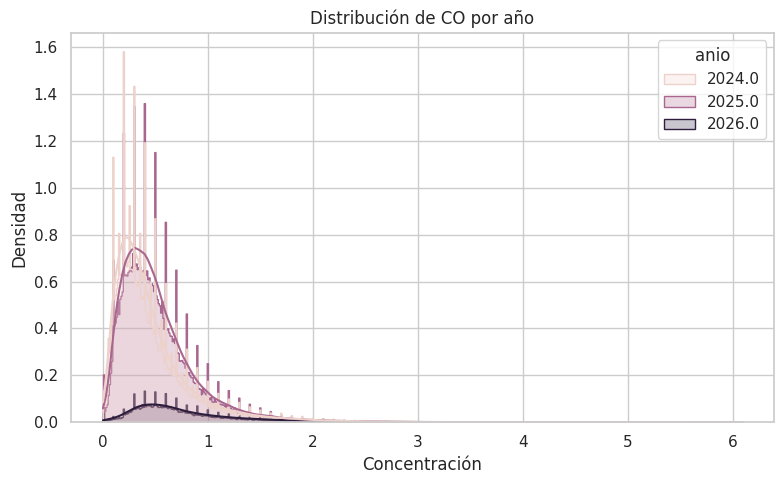

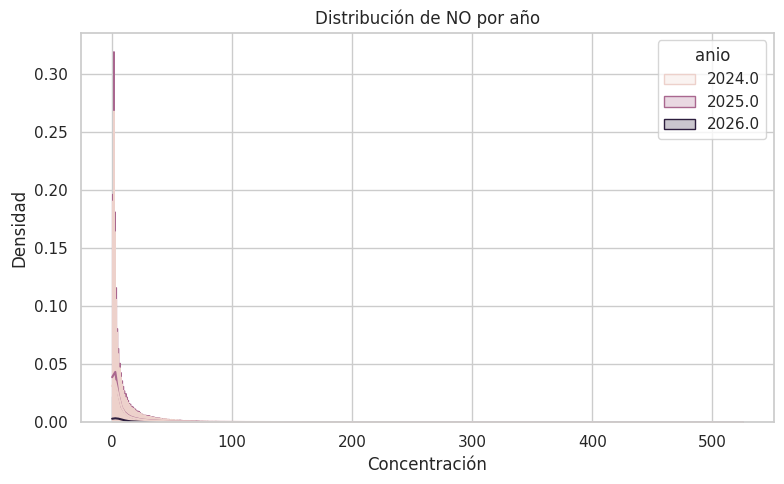

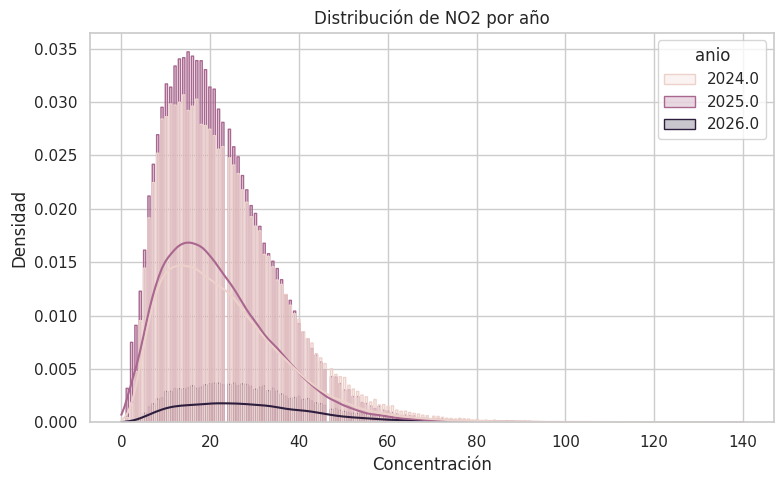

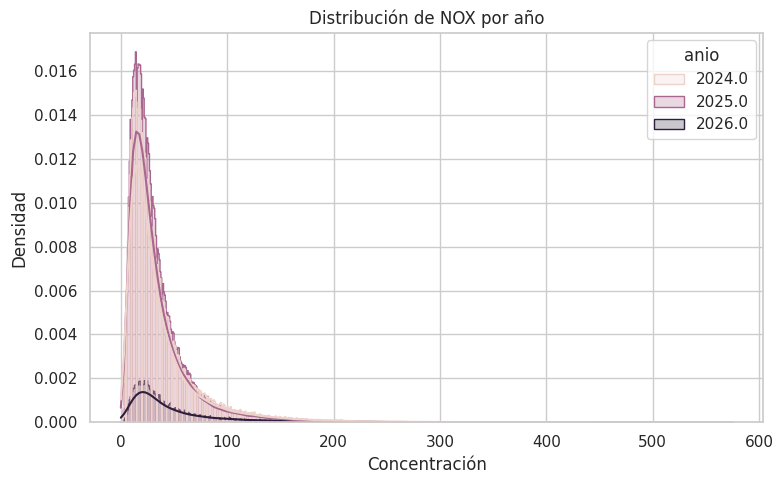

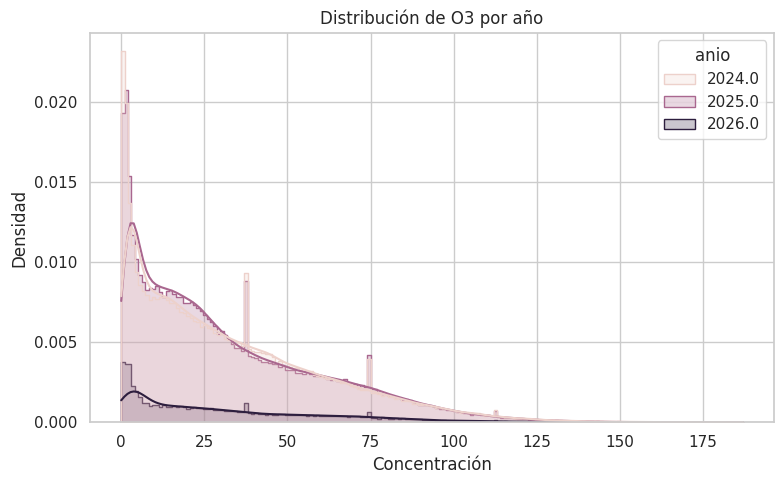

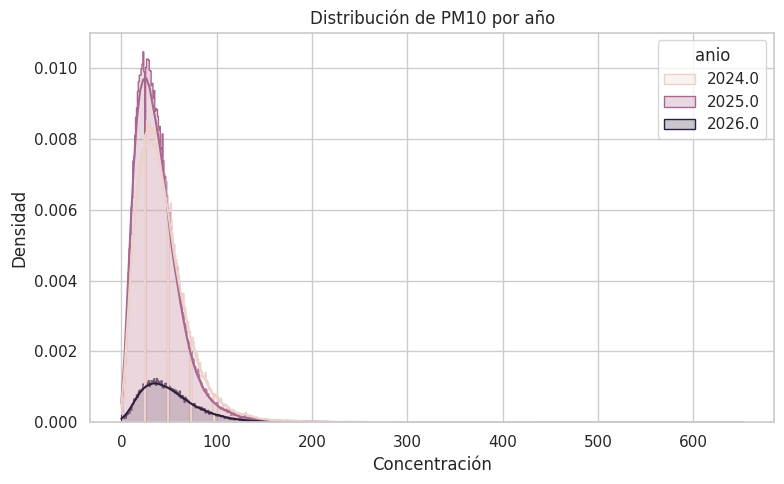

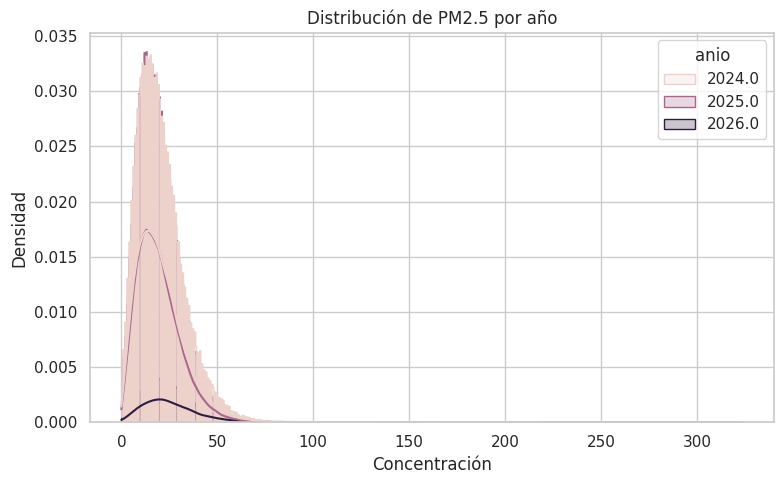

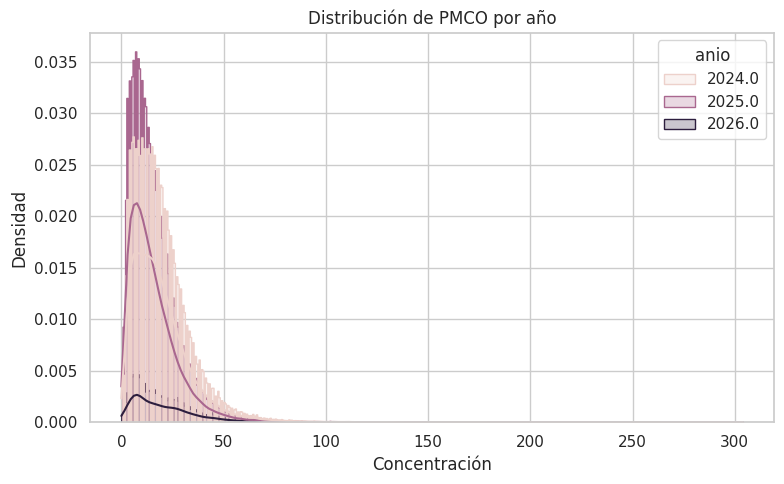

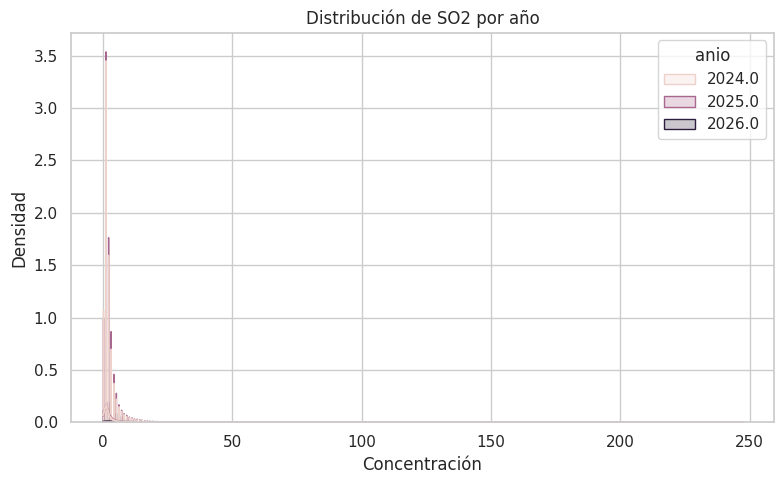

In [31]:
contaminantes = df["contaminante"].unique()

for cont in contaminantes:
    plt.figure(figsize=(8, 5))
    subset = df[df["contaminante"] == cont]
    sns.histplot(data=subset, x="valor", hue="anio", kde=True, element="step", stat="density")
    plt.title(f"Distribución de {cont} por año")
    plt.xlabel("Concentración")
    plt.ylabel("Densidad")
    plt.tight_layout()
    plt.show()

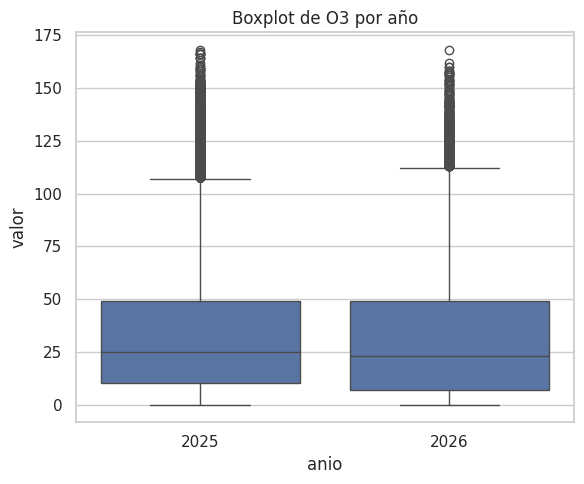

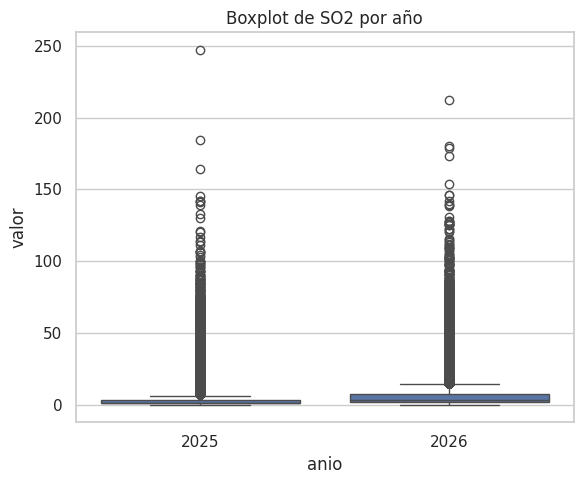

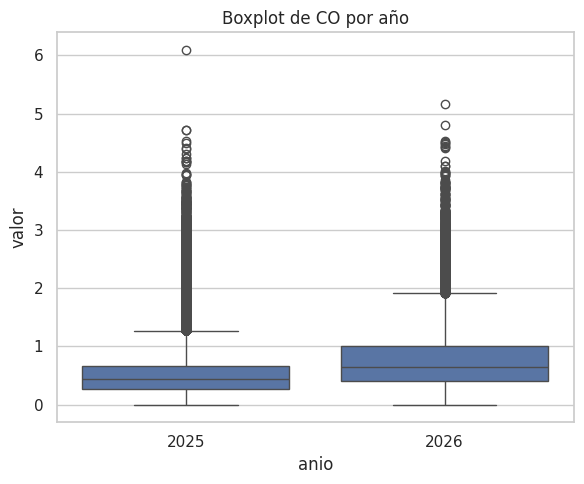

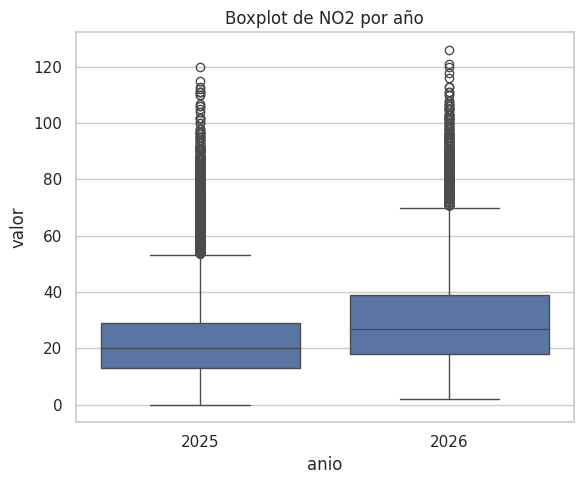

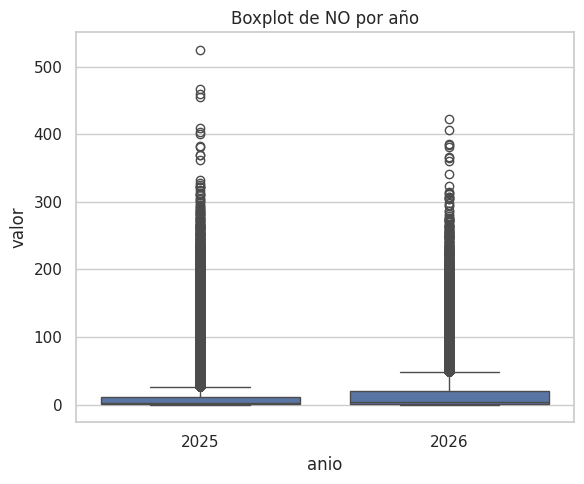

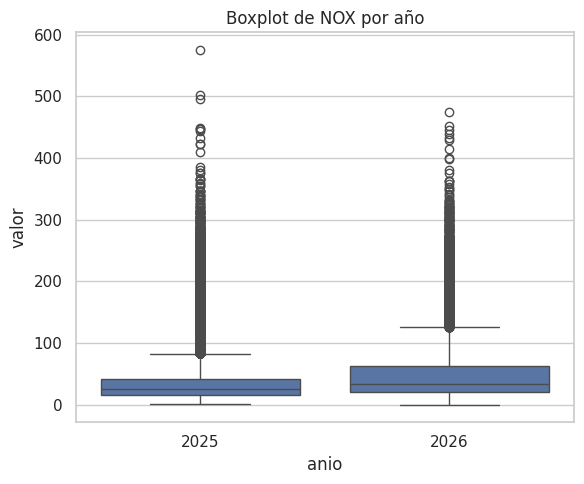

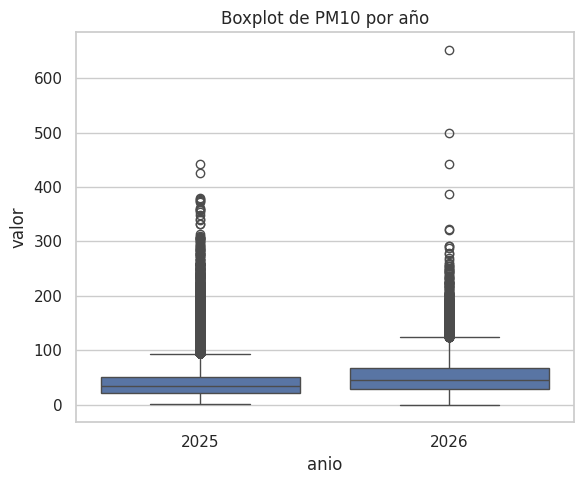

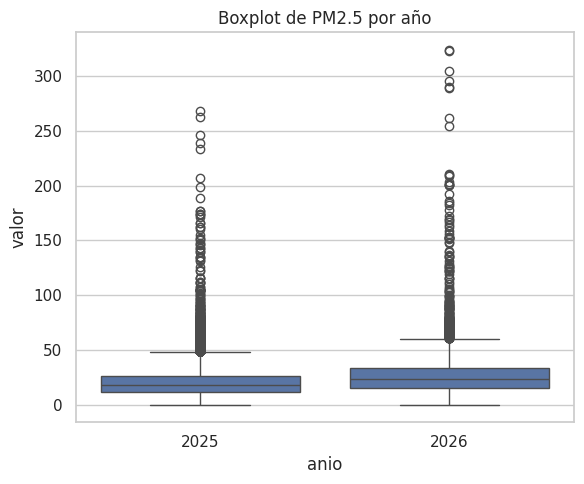

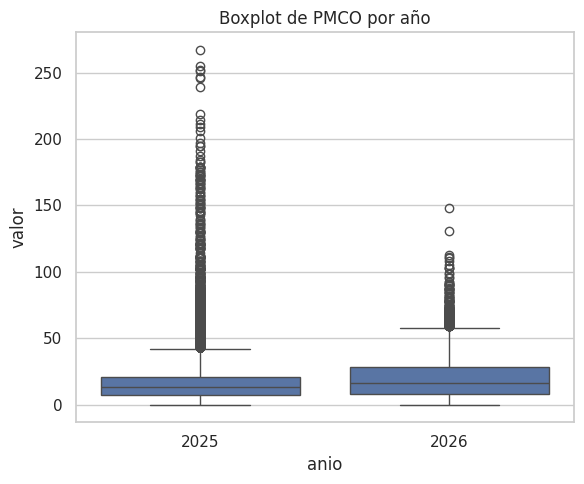

In [23]:
# Boxplots comparativos por año
for cont in contaminantes:
    plt.figure(figsize=(6, 5))
    subset = df[df["contaminante"] == cont]
    sns.boxplot(data=subset, x="anio", y="valor")
    plt.title(f"Boxplot de {cont} por año")
    plt.tight_layout()
    plt.show()


## 7. Conclusiones

**Contaminantes más variables:**
De todos los contaminantes analizados, el NO y el SO₂ son los que presentan mayor variabilidad. Su coeficiente de variación es superior a 1.6 en los tres años, lo que significa que sus valores cambian bastante y no son tan constantes. En general, la mayoría de las mediciones son bajas, pero de vez en cuando aparecen picos muy altos. Por ejemplo, el NO llegó a alcanzar los 525 µg/m³, aunque su promedio se encuentra alrededor de 12-20 µg/m³. Por otro lado, el NO₂ presenta un comportamiento mucho más estable, con un coeficiente de variación aproximado de 0.55-0.60.

**Distribuciones sesgadas a la derecha:**
En los contaminantes analizados se observa que la media suele ser considerablemente mayor que la mediana, mientras que la moda es todavía más baja. Un ejemplo claro es el NO en 2024, donde la media fue de 13.76, la mediana de 3.00 y la moda de 1.00. Esto nos indica que la mayor parte de las mediciones se mantiene en niveles bajos, pero algunos eventos con concentraciones muy altas terminan elevando el promedio. Por esta razón, para representar mejor lo que sería un "día típico", la mediana resulta más útil que la media.

**Comportamiento de 2024 a 2026:**
Al comparar los tres años, se observa que en 2025 la mayoría de los contaminantes disminuyó ligeramente con respecto a 2024. Sin embargo, en 2026 se presenta un aumento considerable. Por ejemplo, el PM10 pasó de 43.5 a 38.9 y después a 52.1, mientras que el NOX pasó de 37.2 a 34.2 y posteriormente a 49.8. El caso más notable es el SO₂, que pasó de 2.6 en 2024 y 2.8 en 2025 a 7.0 en 2026.

Aun así, este aumento no necesariamente significa que la contaminación esté empeorando de manera permanente. Esto se debe a que los datos de 2026 únicamente corresponden a enero y febrero, mientras que los datos de 2024 y 2025 abarcan todo el año. Además, enero y febrero suelen presentar condiciones que favorecen la acumulación de contaminantes en la CDMX. Por lo tanto, sería necesario contar con datos de todo 2026 para poder hablar de una tendencia real a largo plazo.

**Contaminantes con mayor dispersión:**
En términos de dispersión absoluta, el PM10 y el NOX son los que presentan los valores más altos. Sus máximos alcanzan 652 y 575, respectivamente, lo que muestra que, aunque normalmente sus concentraciones pueden mantenerse en niveles moderados, también pueden presentarse episodios puntuales con niveles considerablemente elevados de contaminación.
